In [1]:
import torch
from torch import nn
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import requests
from pathlib import Path
from helper_functions import plot_predictions, plot_decision_boundary

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 6. The missing piece: Non - linearity

(Date - 3/Apr/2026)

### 6.1 Recreating non-linear data (red and blue circles)

In [3]:
n_samples = 1000

X, Y = make_circles(n_samples, noise=0.03, random_state=42)
print(len(X), len(Y), "\n")
print(X[:5], "\n") # Prints the first 5 values of X
print(Y[:5])

1000 1000 

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]] 

[1 1 1 1 0]


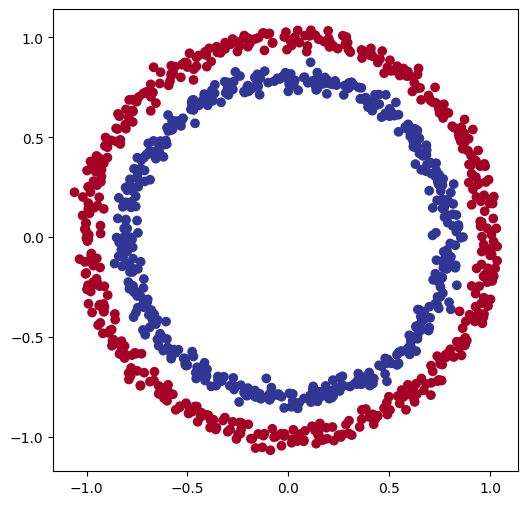

In [4]:
plt.figure(figsize=(6,6))
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=Y,
            cmap=plt.cm.RdYlBu);

In [5]:
X = torch.from_numpy(X).type(torch.float)
Y = torch.from_numpy(Y).type(torch.float)

X_train, X_test, Y_train, Y_test = train_test_split(X,
                                                    Y,
                                                    test_size = 0.2,#  0.2 = 20% of data will be test and the rest will be for training
                                                    random_state = 42)

In [6]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    accuracy = (correct / len(y_pred)) * 100 
    return accuracy

### 6.2 Building a model with non-linearity

* Linear = straight line
* Non-linear = Non-straight line (e.g. a curve)

In [7]:
# Build model with non-linear activation function
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
print(model_3)

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


### 6.3 Loss function, an optimizer, the training and the testing loops.

In [8]:
# Setup loss and optimizer 
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

In [9]:
torch.manual_seed(42)

X_train, Y_train = X_train.to(device), Y_train.to(device)
X_test, Y_test = X_test.to(device), Y_test.to(device)

epochs = 1000

for epoch in range(epochs):
    model_3.train()

    train_logits = model_3(X_train).squeeze()
    train_pred = torch.round(torch.sigmoid(train_logits))

    train_loss = loss_fn(train_logits, Y_train)
    train_acc = accuracy_fn(y_true=Y_train,
                            y_pred=train_pred)

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, test_pred)

        test_acc = accuracy_fn(y_true=Y_test,
                               y_pred=test_pred)
        
    if epoch % 100 == 0:
        print(f"Epoch : {epoch} Loss : {train_loss:.5f} Accuracy : {train_acc:.2f} | Test loss : {test_loss:.5f} Train Accuracy : {train_acc:.2f}")
        


Epoch : 0 Loss : 0.69394 Accuracy : 50.88 | Test loss : 0.61276 Train Accuracy : 50.88
Epoch : 100 Loss : 0.68631 Accuracy : 52.12 | Test loss : 0.64532 Train Accuracy : 52.12
Epoch : 200 Loss : 0.68239 Accuracy : 54.12 | Test loss : 0.64755 Train Accuracy : 54.12
Epoch : 300 Loss : 0.67631 Accuracy : 63.75 | Test loss : 0.64247 Train Accuracy : 63.75
Epoch : 400 Loss : 0.66859 Accuracy : 59.75 | Test loss : 0.62637 Train Accuracy : 59.75
Epoch : 500 Loss : 0.65781 Accuracy : 60.75 | Test loss : 0.60477 Train Accuracy : 60.75
Epoch : 600 Loss : 0.64130 Accuracy : 63.62 | Test loss : 0.58387 Train Accuracy : 63.62
Epoch : 700 Loss : 0.60971 Accuracy : 70.00 | Test loss : 0.57509 Train Accuracy : 70.00
Epoch : 800 Loss : 0.53623 Accuracy : 94.25 | Test loss : 0.55318 Train Accuracy : 94.25
Epoch : 900 Loss : 0.41262 Accuracy : 98.50 | Test loss : 0.44750 Train Accuracy : 98.50


In [18]:
train_logits[:5], Y_train[:5]

(tensor([ 1.2720, -0.9184, -1.9533, -1.2517,  1.0315], grad_fn=<SliceBackward0>),
 tensor([1., 0., 0., 0., 1.]))

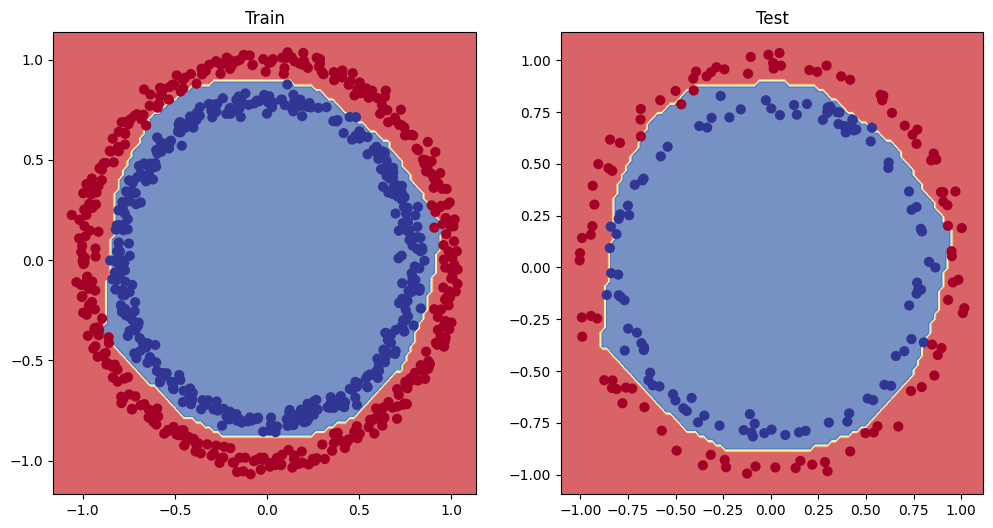

In [10]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, Y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, Y_test) # model_3 = has non-linearity

## 7. Replicating non-linear activation functions

(Date - 4/Apr/2026)

### 7.1 Setting up a tensor

In [11]:
# Create a toy tensor (similar to the data going into our model(s))
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

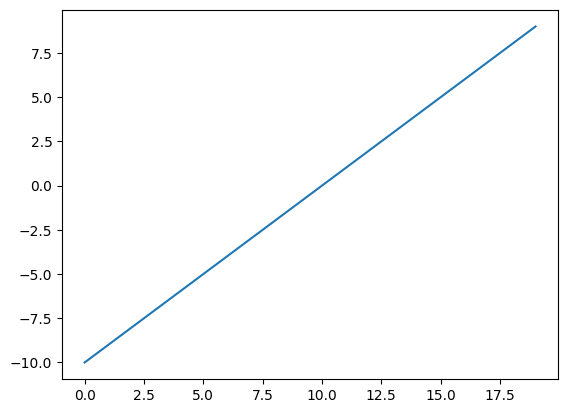

In [12]:
plt.plot(A)

### 7.2 ReLU (Rectified Linear Unit)

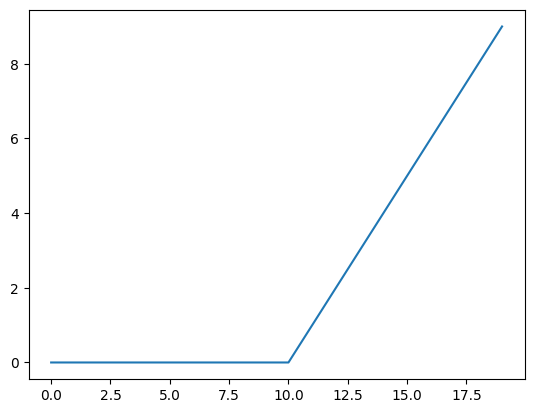

In [13]:
plt.plot(torch.relu(A))

In [14]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.maximum(torch.tensor(0), x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

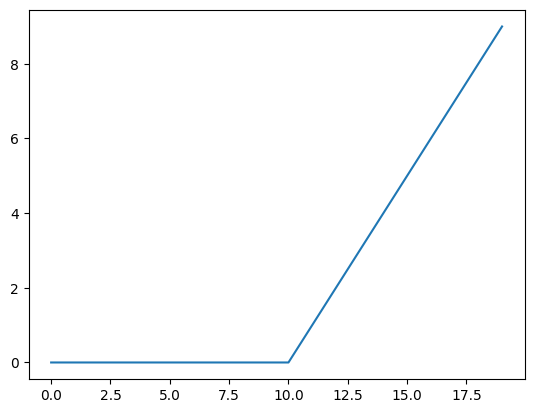

In [15]:
plt.plot(relu(A))

### 7.3 Sigmoid

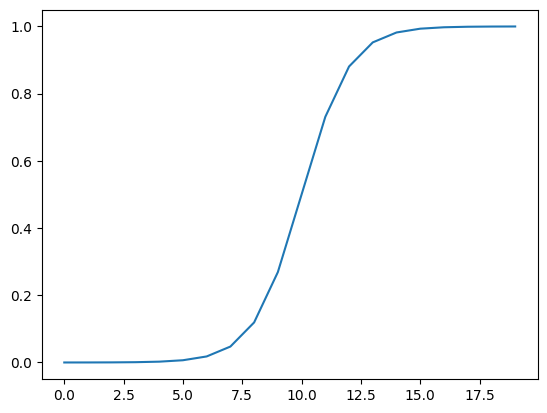

In [16]:
def sigmoid(x: torch.Tensor) -> torch.Tensor:
    return 1/(1+torch.exp(-x))

plt.plot(torch.sigmoid(A))

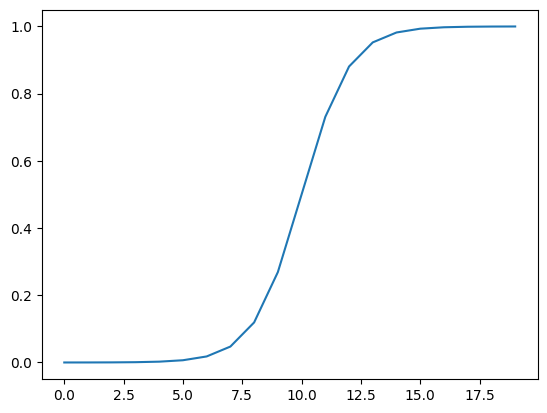

In [17]:
plt.plot(sigmoid(A))

Everything is put all together with a multi-class classification problem in the next file (25.ipynb).